In [1]:
import os
import pandas as pd
import shutil
from tqdm import tqdm

In [2]:
# Paths
RAW_DATA_PATH = "../data_raw/BreaKHis_v1"
EXCEL_PATH = "../data_raw/Folds.csv"
OUTPUT_PATH = "../data_processed"

In [3]:
# Load Excel
df = pd.read_csv(EXCEL_PATH)

In [4]:
# Filter 200X
df = df[df['mag'] == 200]

In [5]:
df.head()

,fold,mag,grp,filename
30,1,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
31,1,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
32,1,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
33,1,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
34,1,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...


In [6]:
print("Total images at 200X:", len(df))

Total images at 200X: 10065


In [7]:
# Create folders
for split in ["train", "val", "test"]:
    for cls in ["benign", "malignant"]:
        os.makedirs(os.path.join(OUTPUT_PATH, split, cls), exist_ok=True)

# Function to extract label
def get_label(filename):
    if "_B_" in filename:
        return "benign"
    else:
        return "malignant"

In [8]:
# Split ratios
train_ratio = 0.7
val_ratio = 0.15

In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
train_end = int(len(df) * train_ratio)
val_end = int(len(df) * (train_ratio + val_ratio))

train_df = df[:train_end]
val_df = df[train_end:val_end]
test_df = df[val_end:]

In [11]:
# Copy function
def copy_images(dataframe, split):
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        relative_path = row['filename']
        src = os.path.join(RAW_DATA_PATH, relative_path.split("BreaKHis_v1/")[1])

        label = get_label(relative_path)

        dst = os.path.join(OUTPUT_PATH, split, label, os.path.basename(src))

        try:
            shutil.copy(src, dst)
        except:
            pass

In [12]:
# Copy images
copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

print("Dataset prepared successfully!")

  0%|          | 0/7045 [00:00<?, ?it/s]

100%|██████████| 1510/1510 [00:01<00:00, 1161.99it/s]

Dataset prepared successfully!


In [13]:
def count_images(path):
    count = 0
    for root, dirs, files in os.walk(path):
        count += len(files)
    return count

print("Train:", count_images("../data_processed/train"))
print("Validation:", count_images("../data_processed/val"))
print("Test:", count_images("../data_processed/test"))

Train: 2010
Validation: 1117
Test: 1133


In [14]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_random_image(data_dir):
    classes = os.listdir(data_dir)
    
    # Pick random class
    chosen_class = random.choice(classes)
    class_path = os.path.join(data_dir, chosen_class)
    
    # Pick random image
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)
    
    # Load image
    img = Image.open(image_path)
    
    # Show image
    plt.imshow(img)
    plt.title(f"Class: {chosen_class}")
    plt.axis("off")
    plt.show()

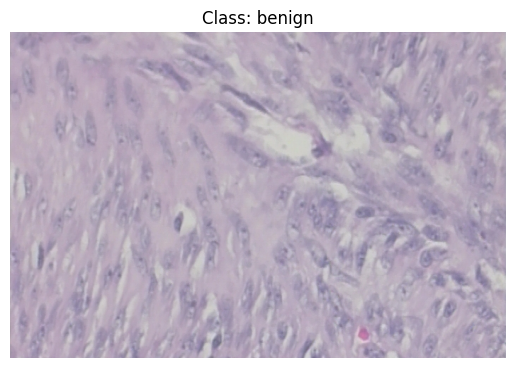

In [18]:
show_random_image("../data_processed/train")

In [19]:
def show_multiple_images(data_dir, num_images=6):
    classes = os.listdir(data_dir)
    
    plt.figure(figsize=(12, 8))
    
    for i in range(num_images):
        chosen_class = random.choice(classes)
        class_path = os.path.join(data_dir, chosen_class)
        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)
        
        img = Image.open(image_path)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(chosen_class)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

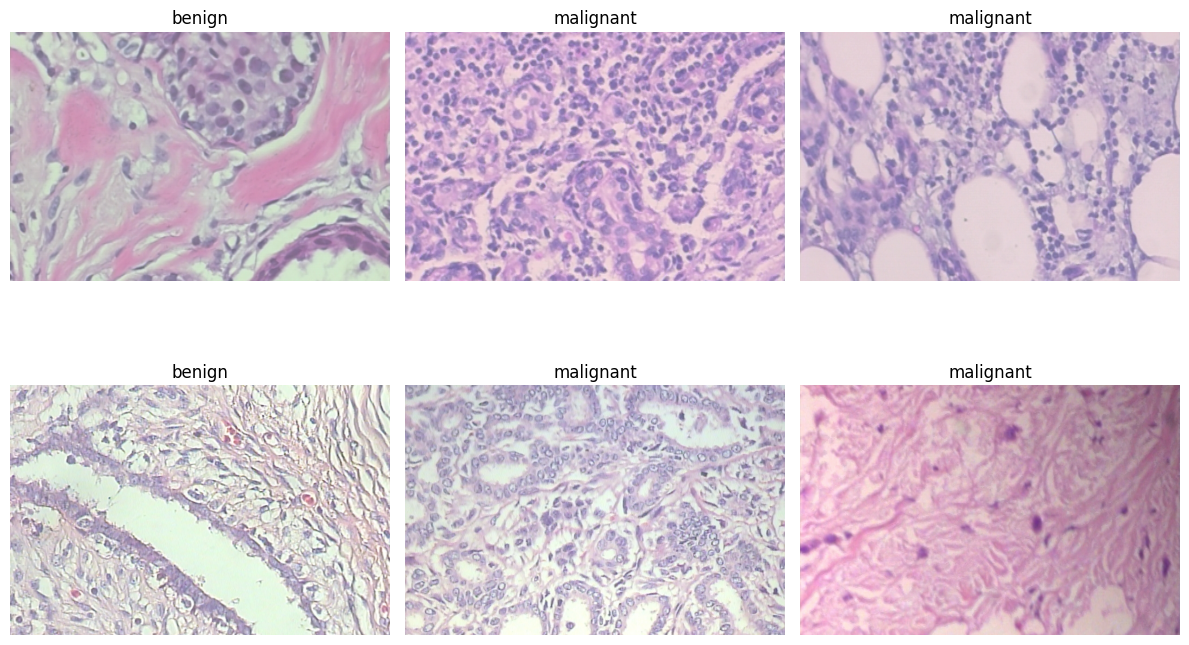

In [20]:
show_multiple_images("../data_processed/train")

EDA

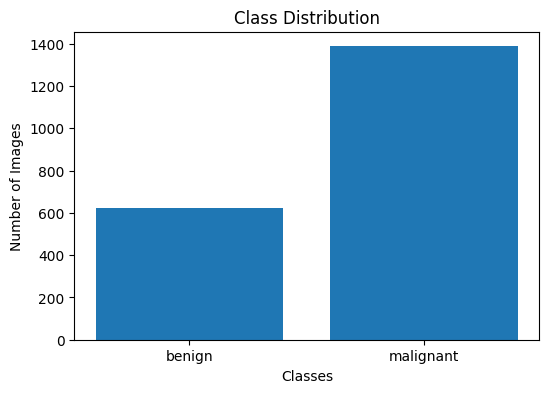

In [21]:
def plot_class_distribution(data_dir):
    classes = os.listdir(data_dir)
    counts = []
    
    for cls in classes:
        path = os.path.join(data_dir, cls)
        counts.append(len(os.listdir(path)))
    
    plt.figure(figsize=(6,4))
    plt.bar(classes, counts)
    plt.title("Class Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution("../data_processed/train")

In [22]:
def check_image_sizes(data_dir, num_samples=20):
    widths = []
    heights = []
    
    classes = os.listdir(data_dir)
    
    for cls in classes:
        class_path = os.path.join(data_dir, cls)
        images = os.listdir(class_path)[:num_samples]
        
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            w, h = img.size
            
            widths.append(w)
            heights.append(h)
    
    print("Average Width:", sum(widths)/len(widths))
    print("Average Height:", sum(heights)/len(heights))

In [23]:
check_image_sizes("../data_processed/train")

Average Width: 700.0
Average Height: 460.0


In [24]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [25]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../data_processed/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../data_processed/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2010 files belonging to 2 classes.
Found 1117 files belonging to 2 classes.


In [26]:
#normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Data Augmentation

In [27]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [30]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Input(shape=(224, 224, 3)))

# Data Augmentation
model.add(data_augmentation)

# -------- BLOCK 1 --------
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# -------- BLOCK 2 --------
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# -------- BLOCK 3 --------
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# -------- BLOCK 4 --------
model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# FC Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))

# Output
model.add(layers.Dense(1, activation='sigmoid'))

In [31]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,115,457 (19.51 MB)

 Trainable params: 5,115,457 (19.51 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7104 - loss: 0.5655 - val_accuracy: 0.7681 - val_loss: 0.4549
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8338 - loss: 0.4529 - val_accuracy: 0.8738 - val_loss: 0.3950
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8353 - loss: 0.4406 - val_accuracy: 0.8201 - val_loss: 0.4193
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8453 - loss: 0.4208 - val_accuracy: 0.8532 - val_loss: 0.4026
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8488 - loss: 0.4127 - val_accuracy: 0.8236 - val_loss: 0.4136
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8353 - loss: 0.4326 - val_accuracy: 0.8362 - val_loss: 0.4272
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 667ms/step - accuracy: 0.8587 - loss: 0.3986 - val_accuracy: 0.8532 - val_loss: 0.3971
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 607ms/step - accuracy: 0.8423 - loss: 0.4157 - val_accuracy: 0.8738

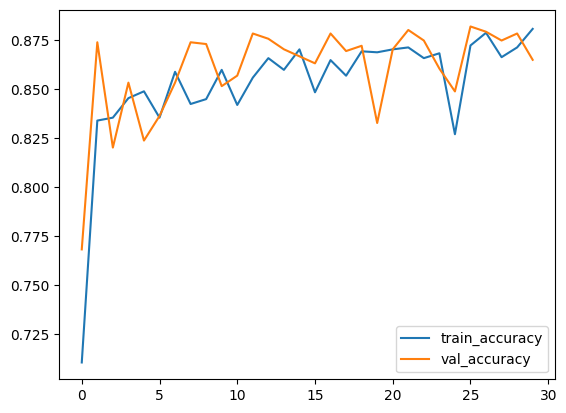

In [34]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

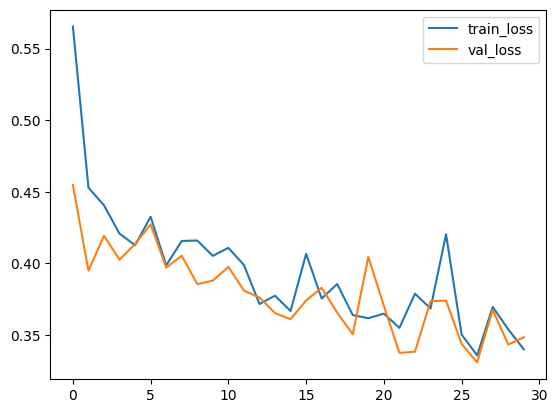

In [35]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()